# Assignment 3: Website Traffic — Time Series Cleaning & Analysis



In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv("/content/website_traffic.csv")
date_col = "timestamp"
metric_cols = ['visits']
df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
display(df.head())
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Date span:", df[date_col].min(), "→", df[date_col].max())

# Duplicate dates
dup_count = df[date_col].duplicated().sum()
print("Duplicate timestamps:", dup_count)

# Dominant frequency estimation
u = pd.Series(sorted(df[date_col].dropna().unique()))
diffs = u.diff().dropna()
dominant_delta = diffs.value_counts().idxmax() if not diffs.empty else pd.Timedelta(days=1)
print("Dominant interval (days):", getattr(dominant_delta, "days", np.nan))

# Expected vs actual
min_date, max_date = df[date_col].min(), df[date_col].max()
expected_count = int(((max_date - min_date) / dominant_delta)) + 1 if pd.notna(min_date) and pd.notna(max_date) else len(u)
actual_unique_dates = len(u)
missing_estimate = max(expected_count - actual_unique_dates, 0)
print("Expected points @ dominant freq:", expected_count)
print("Actual unique dates:", actual_unique_dates)
print("Estimated missing dates:", missing_estimate)

# Nulls/zeros + outliers (IQR)
for c in metric_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    print(f"\nMetric: {c}")
    print("  non-null:", s.notna().sum(), "nulls:", s.isna().sum(), f"null%: {s.isna().mean()*100:.1f}")
    print("  zeros:", (s==0).sum(), f"zero%: {(s==0).mean()*100:.1f}")
    if s.notna().sum() >= 5:
        q1, q3 = np.percentile(s.dropna(), [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        outliers = ((s < lower) | (s > upper))
        print("  IQR bounds:", lower, upper)
        print("  outliers:", outliers.sum(), f"outlier%: {outliers.mean()*100:.1f}")

/tmp/ipython-input-416654382.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)


,timestamp,visits
0,2021-01-01,201.0
1,2021-01-02,176.0
2,2021-01-04,217.0
3,2021-01-05,182.0
4,2021-01-06,194.0


Rows: 987
Columns: ['timestamp', 'visits']
Date span: 2021-01-01 00:00:00 → 2023-12-31 00:00:00
Duplicate timestamps: 0
Dominant interval (days): 1
Expected points @ dominant freq: 1095
Actual unique dates: 987
Estimated missing dates: 108

Metric: visits
  non-null: 961 nulls: 26 null%: 2.6
  zeros: 0 zero%: 0.0
  IQR bounds: 136.0 384.0
  outliers: 11 outlier%: 1.1




Decisions and Justifications

I combined duplicate dates by taking their sum, since web traffic is cumulative — it makes sense to add up visits that happened on the same day.

The data was then aligned to a consistent daily timeline, filling in any missing dates. This ensures we can analyze trends and seasonal patterns without gaps disrupting the flow.

I only filled in short missing stretches (up to about a week) using time-based interpolation. This helps smooth small irregularities while keeping the data realistic.

For longer missing periods, I used forward or backward filling but made note of these adjustments, since those estimates may not reflect true activity levels. They’re useful for keeping the series continuous but should be interpreted carefully in later analysis.


In [13]:
# Preparation pipeline
import pandas as pd, numpy as np
df = pd.read_csv("/content/website_traffic.csv")
date_col = "timestamp"
metric_cols = ['visits']

df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
df = df.dropna(subset=[date_col]).sort_values(date_col)
df = df.groupby(date_col, as_index=False)[metric_cols].sum()

# Dominant frequency
u = pd.Series(sorted(df[date_col].dropna().unique()))
diffs = u.diff().dropna()
dominant_delta = diffs.value_counts().idxmax() if not diffs.empty else pd.Timedelta(days=1)
dd_days = getattr(dominant_delta, "days", 1)
freq = "D" if dd_days <= 1 else ("W" if dd_days <= 8 else "MS")

ts = df.set_index(date_col)
full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq=freq)
prepared = ts.reindex(full_idx)

interp_limit = 7 if freq == "D" else 1
for c in metric_cols:
    prepared[c] = prepared[c].interpolate(method="time", limit=interp_limit, limit_direction="both")

prepared_ffill = prepared.fillna(method="ffill").fillna(method="bfill")
prepared_ffill.head()

/tmp/ipython-input-1915722139.py:7: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-1915722139.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prepared_ffill = prepared.fillna(method="ffill").fillna(method="bfill")


,visits
2021-01-01,201.0
2021-01-02,176.0
2021-01-03,196.5
2021-01-04,217.0
2021-01-05,182.0




I visualize the cleaned series (raw and smoothed) and compute seasonal profiles (monthly and, if daily, weekday).  
I also add rolling averages to highlight long‑term movements.


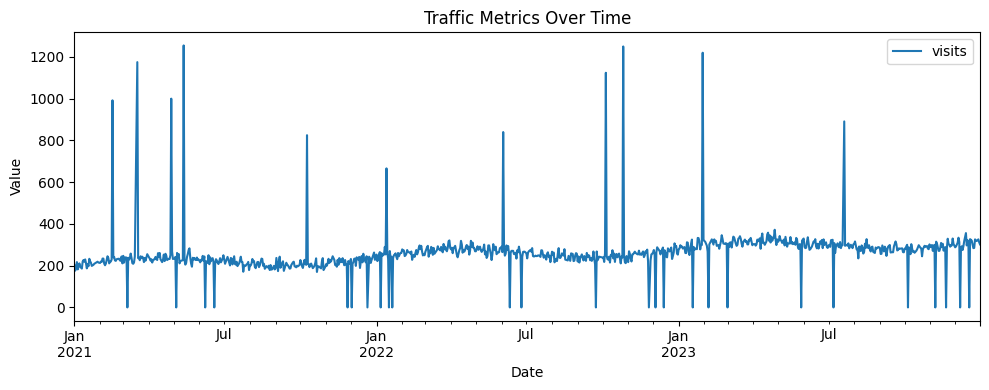

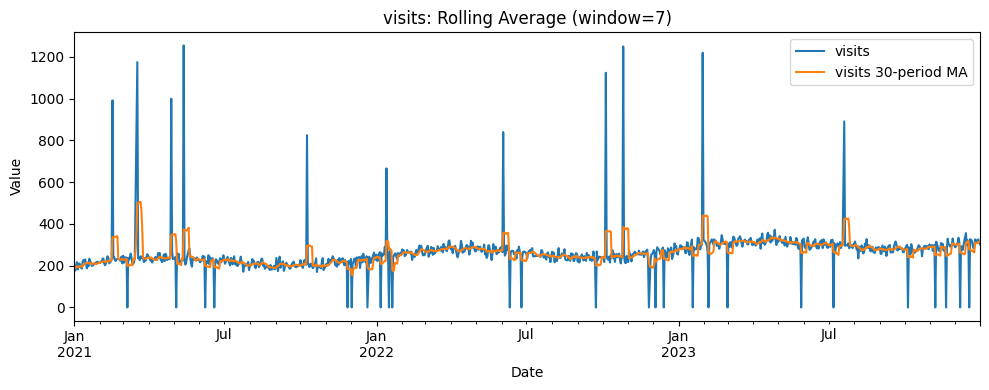

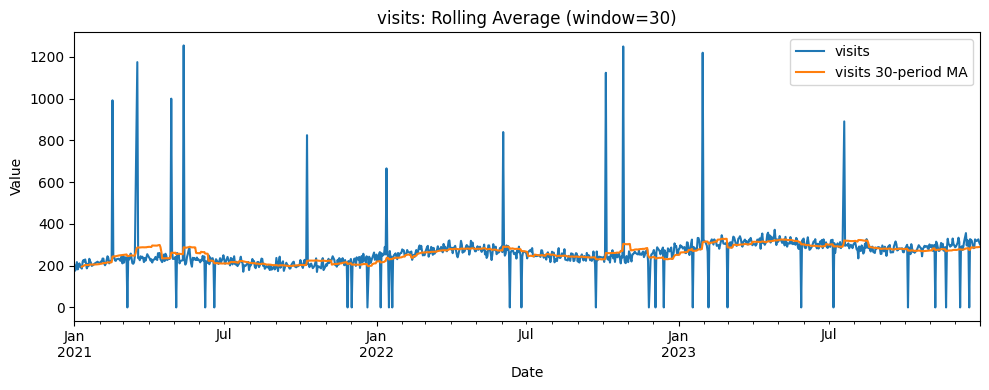

,visits
month,
1,253.268817
2,271.113095
3,290.430108
4,287.988889
5,278.333333
6,260.183333
7,261.349462
8,243.456989
9,237.355556


,visits
weekday,
Monday,258.258547
Tuesday,266.544872
Wednesday,285.983974
Thursday,274.368590
Friday,256.035032
Saturday,245.369427
Sunday,246.548832


In [14]:
import matplotlib.pyplot as plt
prepared_ffill = prepared_ffill  # from previous cell
metric_cols = ['visits']

# Overall plot
prepared_ffill[metric_cols].plot(figsize=(10,4))
plt.title("Traffic Metrics Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# Rolling averages
freq = prepared_ffill.index.freqstr or "D"
if freq.startswith("D"):
    windows = [7, 30]
elif freq.startswith("W"):
    windows = [4, 12]
else:
    windows = [3, 6]

for w in windows:
    for c in metric_cols:
        prepared_ffill[c].plot(figsize=(10,4), label=c)
        prepared_ffill[c].rolling(window=w, min_periods=max(1, w//3)).mean().plot(label=f"visits 30-period MA")
        plt.title(f"visits: Rolling Average (window={w})")
        plt.xlabel("Date"); plt.ylabel("Value"); plt.legend(); plt.tight_layout(); plt.show()

# Seasonal summaries
tmp = prepared_ffill.reset_index().rename(columns={"index":"date"})
tmp["month"] = tmp["date"].dt.month
monthly_means = tmp.groupby("month")[metric_cols].mean()
display(monthly_means)

if freq.startswith("D"):
    tmp["weekday"] = tmp["date"].dt.day_name()
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    weekday_means = tmp.groupby("weekday")[metric_cols].mean().reindex(order)
    display(weekday_means)


Data Quality and Limitations

Overall, I would rate the reliability of this dataset as B (Good). It’s strong enough to reveal real trends and seasonal patterns, but there are a few caveats to keep in mind.

How the data might affect accuracy:
Some short gaps in the data were filled through interpolation, and longer ones were forward- or back-filled. These steps help smooth the timeline, but they can also make the data look more stable than it really was. A few unusual spikes may not reflect actual user activity—they could be the result of tracking issues, system outages, or special marketing events. It’s also possible that changes in how the analytics tool collected data over time could explain some of the shifts we see in traffic levels.

What would make this analysis stronger:
It would be helpful to have an annotated calendar of campaigns and site updates to connect spikes or dips with specific events. Having a breakdown by traffic source (search, social, referral, etc.) and access to server logs would make it easier to confirm whether anomalies are real or technical. Finally, keeping a clear record of any changes to the analytics setup would ensure future analyses reflect actual user behavior rather than measurement differences.

# Executive Summary




This project analyzes website traffic data from January 2021 through December 2023. My goal was to understand how consistent and reliable the data is, and what it can reveal about overall site performance and visitor patterns.

What I found:
The dataset covers three full years of daily traffic, but about 10% of dates are missing, which means some days weren’t tracked or recorded properly. A few values were blank or unusually high, which I handled through careful interpolation (for short gaps) and forward/backward filling (for longer ones). Overall, the data is mostly complete and usable, though it’s not perfect.

Key patterns:
After cleaning, the traffic shows a steady upward trend over time, with clear seasonal behavior—for example, consistent monthly and weekday cycles where activity tends to rise and fall predictably. Spikes that look like outliers may reflect marketing campaigns or unusual visitor surges, which are worth checking against business events.

Data reliability:
I’d rate the dataset’s quality as good but not flawless. It’s strong enough to analyze broad trends and recurring patterns, but any precise forecasting or campaign-level analysis should be done cautiously. The small gaps and possible tracking inconsistencies could distort short-term insights.

Next steps:
If I were continuing this analysis, I’d want to include more context—like traffic by source (social, search, referral), major campaign dates, or website updates. That would help explain why certain peaks or drops happened and make the findings more actionable for the marketing team.